<span style="color: blue;">**Predicting Loan Payback**</span>

**Project Overview**

This project builds a machine learning model to predict whether a borrower will repay a loan or default based on financial indicators, borrower characteristics, and loan details. Supervised classification techniques are applied to identify patterns that distinguish low-risk borrowers from high-risk applicants.

To select the most effective model, multiple algorithms including XGBoost, Random Forest, K-Nearest Neighbors, Decision Tree, and Logistic Regression were evaluated using Stratified Cross-Validation to ensure reliable performance comparison. The best-performing model was then further optimized using Bayesian Optimization for hyperparameter tuning, improving predictive performance before deployment in a Streamlit web application for real-time loan prediction.

**Live Application (Streamlit):**

[https://your-streamlit-app-link-here](https://loanpaybackpredictionrandomforest-j6zzon5knr5rkklmhbkcdr.streamlit.app/)

The deployed web application allows users to input borrower and loan details and receive real-time predictions on loan repayment outcomes.

In [68]:
# Data Handling
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [44]:
# Loading the Dataset
df = pd.read_csv('train.csv')

# Previewing the First Five Rows
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1


In [45]:
# Dataset Dimensions
df.shape

(593994, 13)

In [46]:
# Descriptive Statistics Summary
df.describe().round(2)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.00,593994.00,593994.00,593994.00,593994.00,593994.00,593994.0
mean,296996.50,48212.20,0.12,680.92,15020.30,12.36,0.8
std,171471.44,26711.94,0.07,55.42,6926.53,2.01,0.4
min,0.00,6002.43,0.01,395.00,500.09,3.20,0.0
25%,148498.25,27934.40,0.07,646.00,10279.62,10.99,1.0
50%,296996.50,46557.68,0.10,682.00,15000.22,12.37,1.0
75%,445494.75,60981.32,0.16,719.00,18858.58,13.68,1.0
max,593993.00,393381.74,0.63,849.00,48959.95,20.99,1.0


In [47]:
# Dropping Unnecessary Columns
df.drop(columns=['id'], inplace=True)

In [48]:
# List of columns to check
columns = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# Print unique values for each column
for col in columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in 'gender':
['Female' 'Male' 'Other']
--------------------------------------------------
Unique values in 'marital_status':
['Single' 'Married' 'Divorced' 'Widowed']
--------------------------------------------------
Unique values in 'education_level':
['High School' "Master's" "Bachelor's" 'PhD' 'Other']
--------------------------------------------------
Unique values in 'employment_status':
['Self-employed' 'Employed' 'Unemployed' 'Retired' 'Student']
--------------------------------------------------
Unique values in 'loan_purpose':
['Other' 'Debt consolidation' 'Home' 'Education' 'Vacation' 'Car'
 'Medical' 'Business']
--------------------------------------------------
Unique values in 'grade_subgrade':
['C3' 'D3' 'C5' 'F1' 'D1' 'D5' 'C2' 'C1' 'F5' 'D4' 'C4' 'D2' 'E5' 'B1'
 'B2' 'F4' 'A4' 'E1' 'F2' 'B4' 'E4' 'B3' 'E3' 'B5' 'E2' 'F3' 'A5' 'A3'
 'A1' 'A2']
--------------------------------------------------


In [49]:
# Checking for Missing Values
df.isnull().sum()

,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0
loan_purpose,0


In [50]:
# Checking for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [51]:
# Dataset Information Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 54.4+ MB


In [52]:
# Identifying Numeric and Categorical Columns
num = df.select_dtypes(include=['int64', 'float64']).columns
cat = df.select_dtypes(include=['object']).columns

print("Numeric columns:", num)
print("Categorical columns:", cat)

Numeric columns: Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')
Categorical columns: Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')


**EXPLORATORY DATA ANALYSIS**

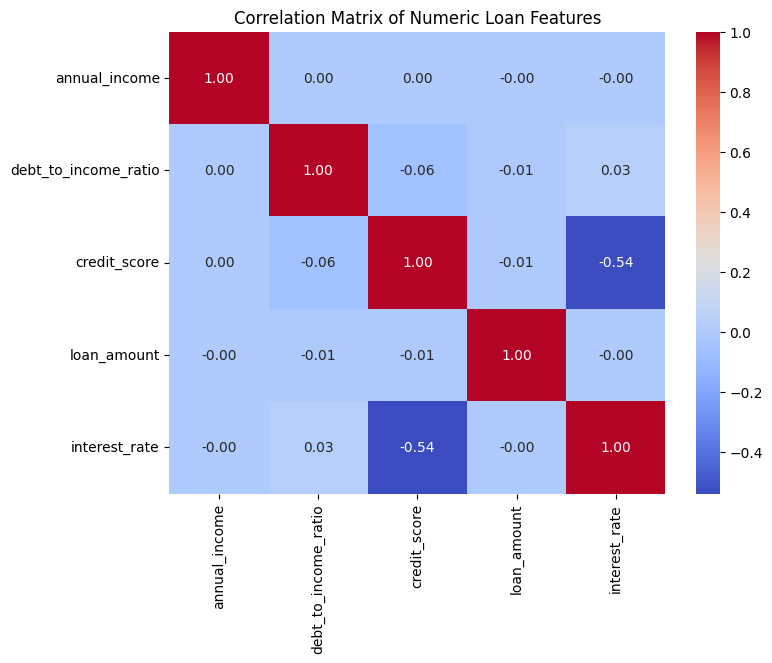

In [53]:
# List of numeric columns
num = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

# Calculate correlation matrix
corr = df[num].corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Loan Features")
plt.show()

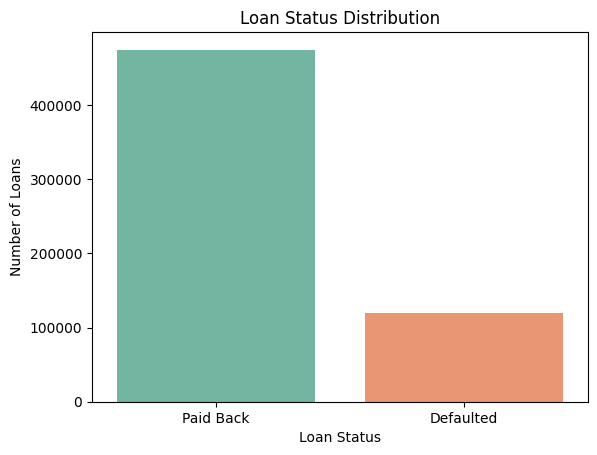

loan_status_label
Paid Back    474494
Defaulted    119500
Name: count, dtype: int64


In [54]:
# Visualizing Target Variable: Loan Status
df['loan_status_label'] = df['loan_paid_back'].map({1: 'Paid Back', 0: 'Defaulted'})

# Plot the distribution
sns.countplot(x='loan_status_label', data=df, palette='Set2')
plt.title("Loan Status Distribution")
plt.ylabel("Number of Loans")
plt.xlabel("Loan Status")
plt.show()

# Print proportions
print(df['loan_status_label'].value_counts())


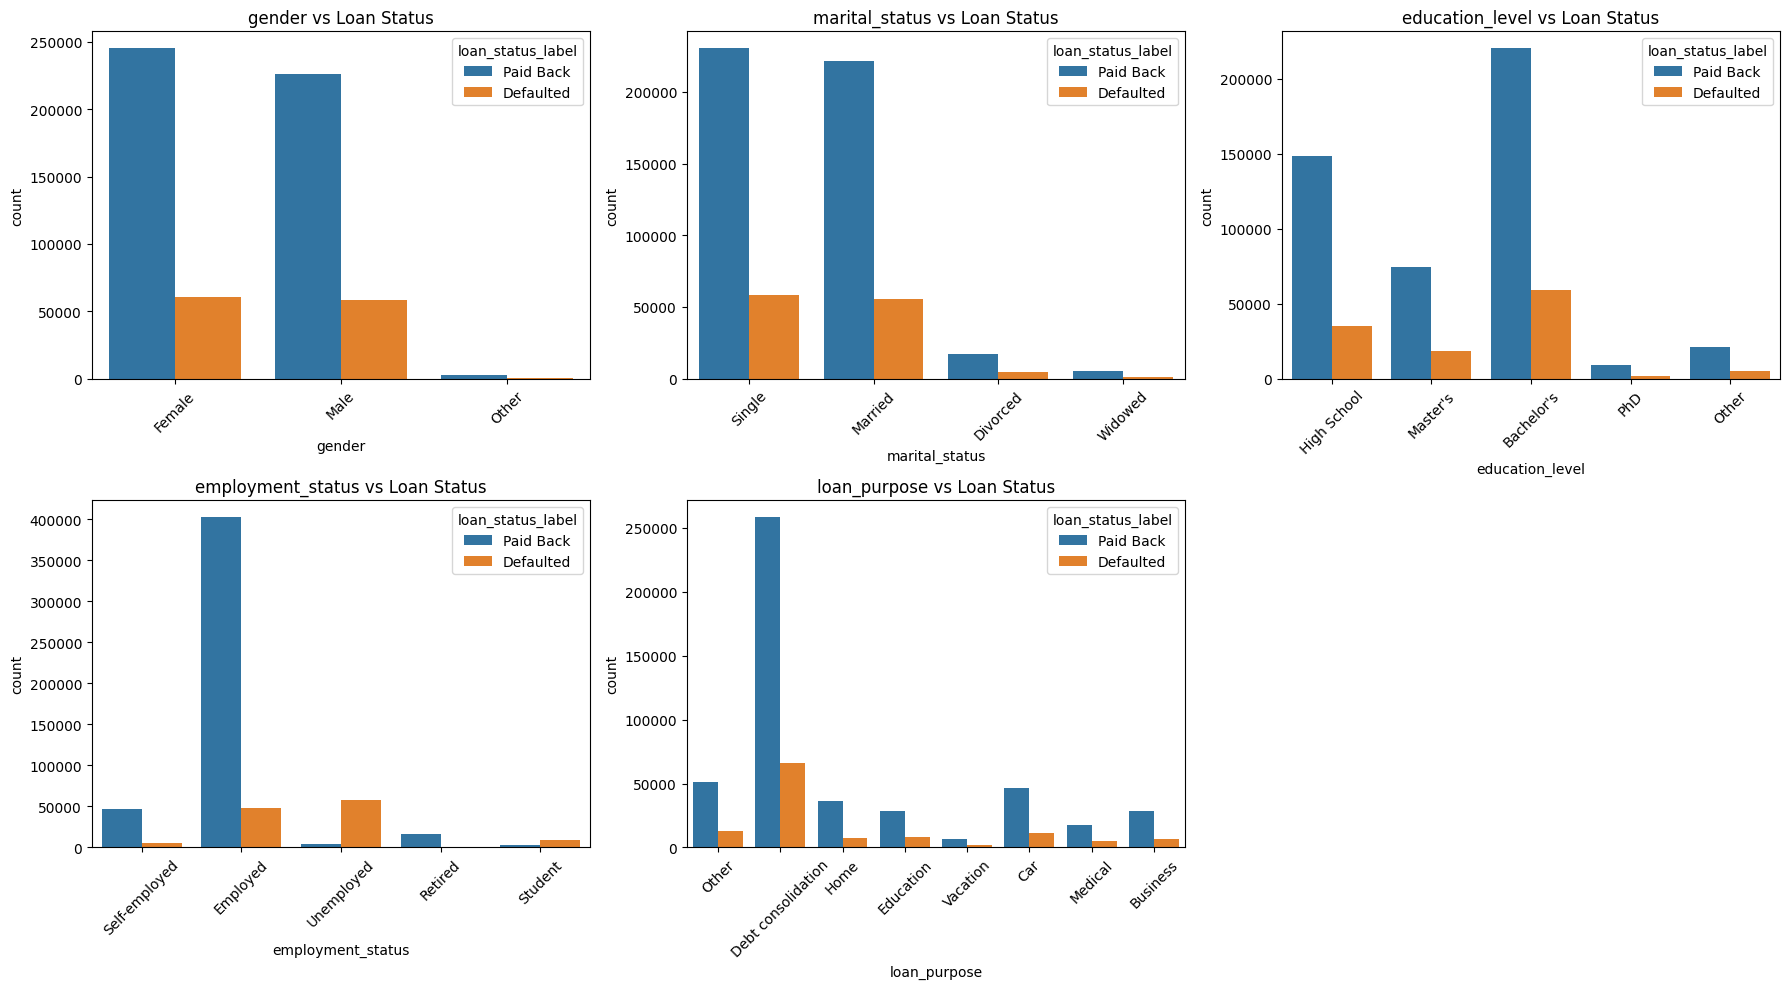

In [55]:
# Categorical Features vs Loan Status
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']

# Create 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='loan_status_label', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].tick_params(axis='x', rotation=45)


fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

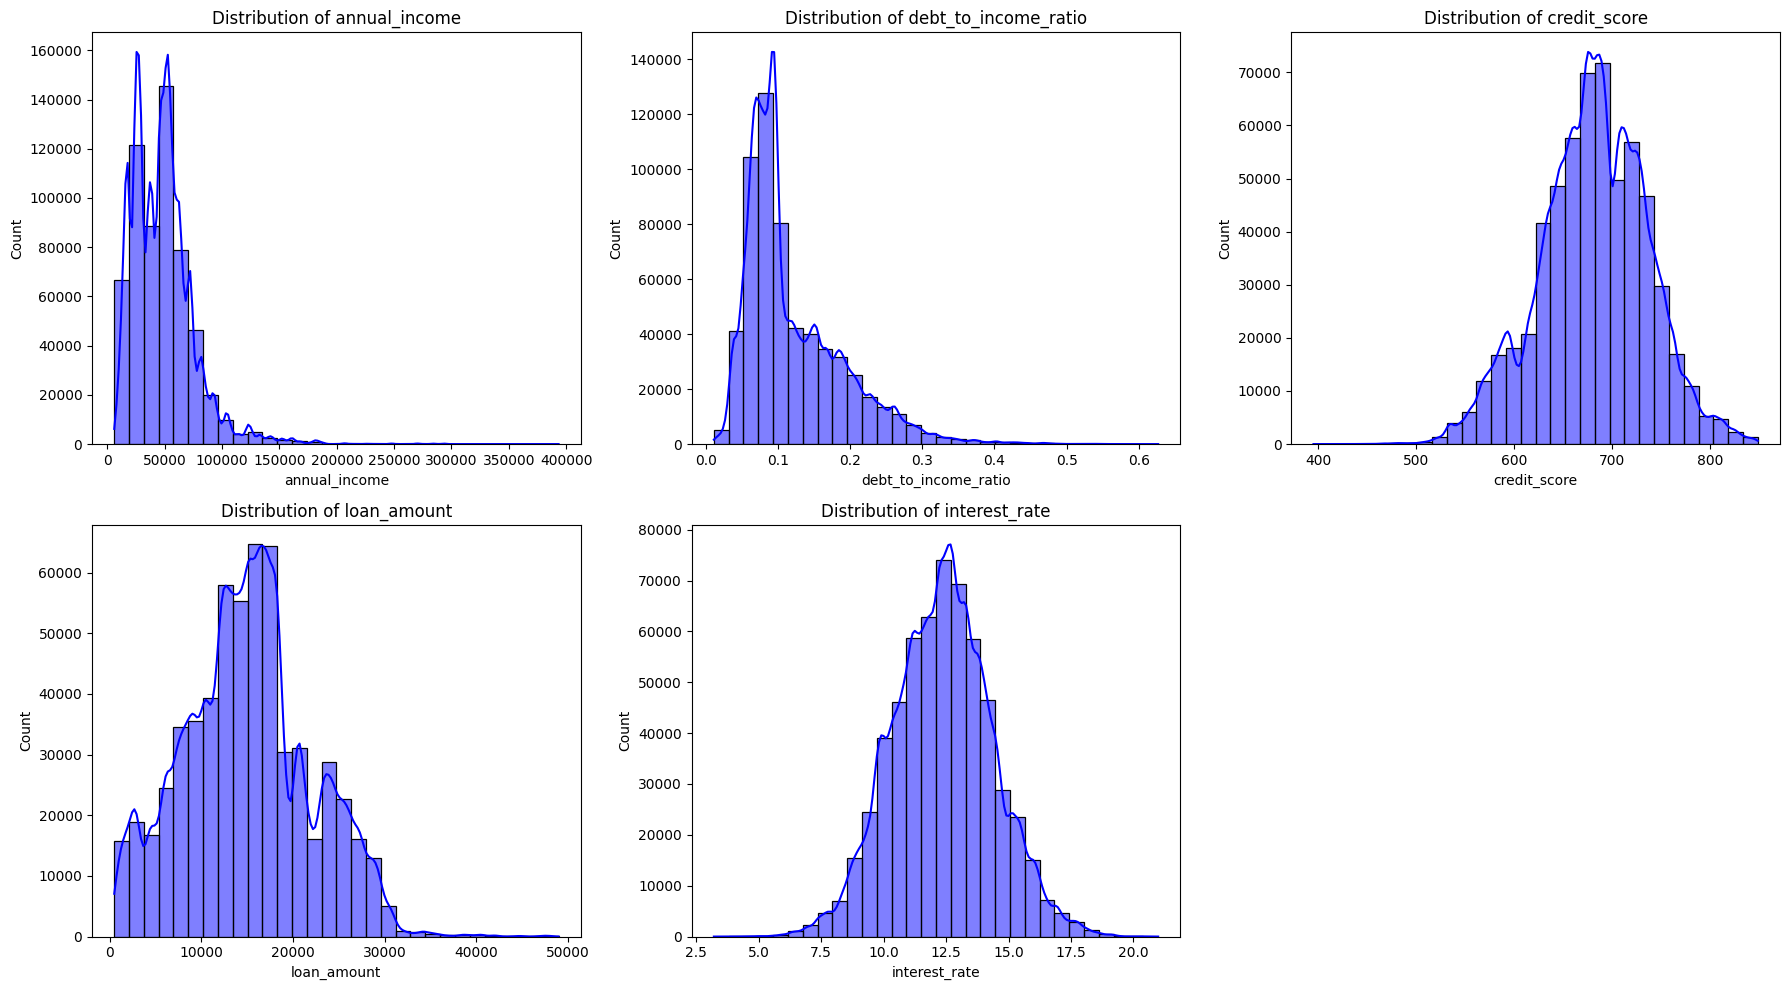

In [56]:
# Distribution of Numerical Features
num_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

# Histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='blue', bins=30)
    axes[i].set_title(f"Distribution of {col}")

# Remove empty subplot (6th one)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

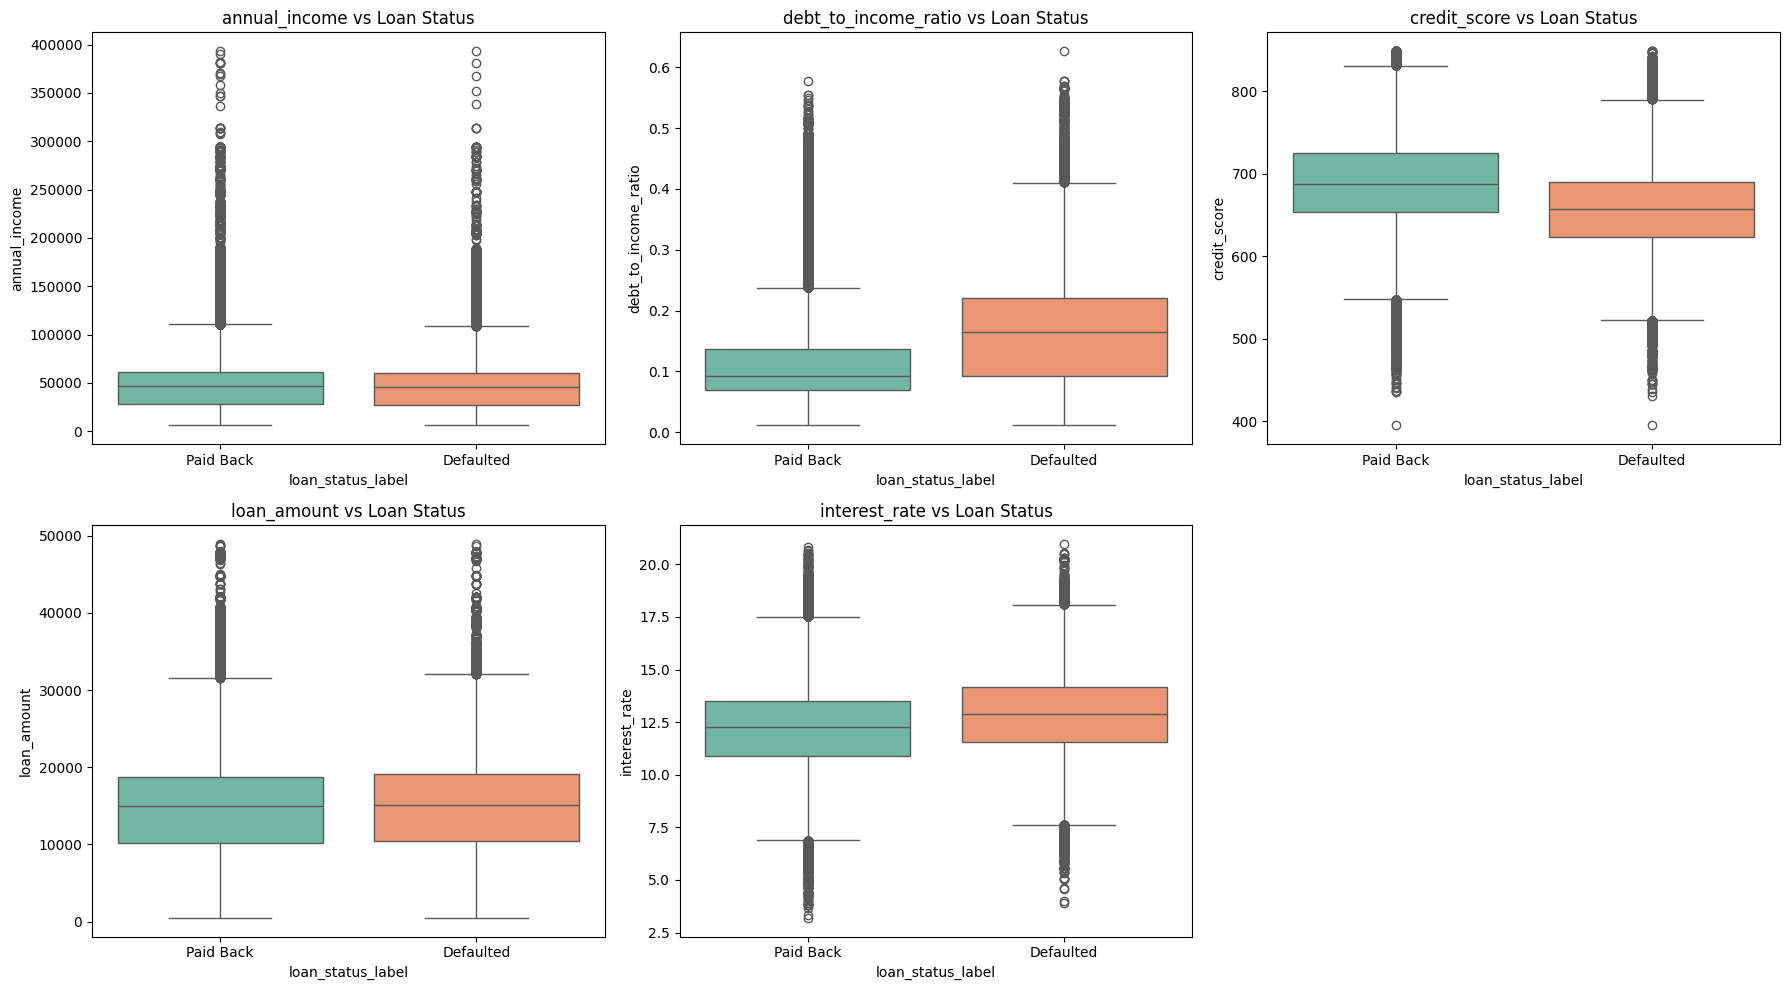

In [57]:
# Boxplots: Numerical Features vs Loan Status
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='loan_status_label', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{col} vs Loan Status")

# Remove empty subplot (6th one)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

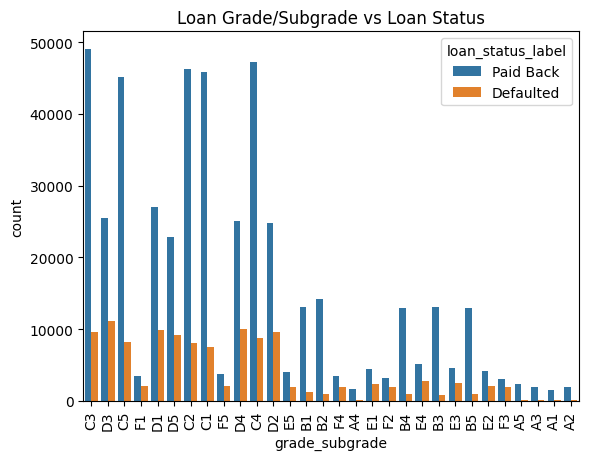

In [58]:
# Loan Grade/Subgrade vs Loan Status
sns.countplot(x='grade_subgrade', hue='loan_status_label', data=df)
plt.xticks(rotation=90)
plt.title("Loan Grade/Subgrade vs Loan Status")
plt.show()

**ENCODING**

In [59]:
# Define the orders
edu_order = ['High School', "Bachelor's", "Master's", 'PhD', 'Other']
grade_order = ['A1','A2','A3','A4','A5',
               'B1','B2','B3','B4','B5',
               'C1','C2','C3','C4','C5',
               'D1','D2','D3','D4','D5',
               'E1','E2','E3','E4','E5',
               'F1','F2','F3','F4','F5']

# Create mapping dictionaries
edu_map = {level: i+1 for i, level in enumerate(edu_order)}
grade_map = {grade: i+1 for i, grade in enumerate(grade_order)}

# Map to new columns in the DataFrame
df['education_level_num'] = df['education_level'].map(edu_map)
df['grade_subgrade_num'] = df['grade_subgrade'].map(grade_map)

# One-Hot Encoding
onehot_cols = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)  # drop_first=True avoids dummy trap

In [60]:
# Updating and Cleaning Categorical Columns
# Drop original categorical columns
df.drop(columns=['education_level','grade_subgrade','loan_status_label'], inplace=True)

# Rename numeric columns to original names (optional)
df.rename(columns={
    'education_level_num': 'education_level',
    'grade_subgrade_num': 'grade_subgrade'
}, inplace=True)

df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,education_level,grade_subgrade,gender_Male,gender_Other,...,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,29367.99,0.084,736,2528.42,13.67,1,1,13,False,False,...,True,False,False,False,False,False,False,False,True,False
1,22108.02,0.166,636,4593.10,12.92,0,3,18,True,False,...,False,False,False,False,True,False,False,False,False,False
2,49566.20,0.097,694,17005.15,9.76,1,1,15,True,False,...,False,False,False,False,True,False,False,False,False,False
3,46858.25,0.065,533,4682.48,16.10,1,1,26,False,False,...,False,False,False,False,True,False,False,False,False,False
4,25496.70,0.053,665,12184.43,10.21,1,1,16,True,False,...,False,False,False,False,False,False,False,False,True,False


In [61]:
# Create Target Variable
# We want to predict 'Default' (Risk). Currently 0=Default, 1=Paid Back.
# Let's set the Target 'y' such that 1 = Default (Positive Class, Minority) and 0 = Paid Back (Negative Class, Majority).
# This makes metrics like Precision/Recall/F1 for Class 1 more meaningful for risk detection.

# Create 'default_target': 1 if loan_paid_back == 0, else 0
df['default_target'] = (df['loan_paid_back'] == 0).astype(int)

X = df.drop(columns=['loan_paid_back', 'default_target'])
y = df['default_target']

print("Target Distribution (1 = Default, 0 = Paid Back):")
print(y.value_counts())

Target Distribution (1 = Default, 0 = Paid Back):
default_target
0    474494
1    119500
Name: count, dtype: int64


In [62]:
# Splitting Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
# Scaling Features Using RobustScaler
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
# Calculate Scale_Pos_Weight for XGBoost
# Since we flipped the labels (1=Default, 0=Paid Back), we are dealing with an imbalanced dataset where 1 is the Minority.
# scale_pos_weight = sum(negative instances) / sum(positive instances)
# This weights the positive class (1) more heavily.

count_neg = (y_train == 0).sum() # Majority (Paid Back)
count_pos = (y_train == 1).sum() # Minority (Default)

ratio = count_neg / count_pos

print(f"Majority (Paid Back): {count_neg}")
print(f"Minority (Default): {count_pos}")
print(f"scale_pos_weight ratio: {ratio:.4f}")

Majority (Paid Back): 379595
Minority (Default): 95600
scale_pos_weight ratio: 3.9707


In [65]:
# Model Selection Using Stratified 5-Fold Cross-Validation
models = {
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV and collect results
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")

# Find best model
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model Based on CV Accuracy:", best_model_name)

XGBoost Average CV Accuracy: 0.8670
RandomForest Average CV Accuracy: 0.9014
KNN Average CV Accuracy: 0.7686
DecisionTree Average CV Accuracy: 0.8523
LogisticRegression Average CV Accuracy: 0.8974

Best Model Based on CV Accuracy: RandomForest


Hyperparameter tuning will be performed on the best (Random Forest) and second-best (XGBoost) models to further improve performance

In [66]:
# Distribution of Target Variable
y.value_counts()

,count
default_target,
0,474494
1,119500


In [71]:
# Installing scikit-optimize for Hyperparameter Tuning
!pip install scikit-optimize

In [72]:
from skopt import BayesSearchCV

<span style="color: blue;">**Extreme Gradient Boosting (XGBoost)**</span>

In [73]:
# XGBoost Classifier with Bayesian Hyperparameter Optimization
# Define XGBoost classifier
xgb = XGBClassifier(
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

# Hyperparameter search space
xgb_search_space = {
    'n_estimators': (100, 500),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform'),
    'gamma': (0, 5),
    'reg_alpha': (1e-3, 10, 'log-uniform'),
    'reg_lambda': (1e-3, 10, 'log-uniform')
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Bayesian Optimization with Accuracy
opt_xgb = BayesSearchCV(
    estimator=xgb,
    search_spaces=xgb_search_space,
    n_iter=20,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# Fit model
opt_xgb.fit(X_train, y_train)

# Output results
print("Best XGBoost Parameters:", opt_xgb.best_params_)
print("Best CV Accuracy:", opt_xgb.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [74]:
# Extract the Best XGBoost Model After Hyperparameter Tuning
best_xgb_model = opt_xgb.best_estimator_

### Model Evaluation
Now that we have the best model from the optimization, let's evaluate its performance on both the training and test sets.
We will look at Accuracy, but also Precision, Recall, and F1-score which are crucial for imbalanced datasets like loan default prediction.
- **Precision**: Of all loans predicted as Default, how many actually defaulted?
- **Recall**: Of all actual Defaults, how many did we catch?

In [75]:
# Evaluate XGBoost Model on Training Data
# Predictions
y_pred_train = best_xgb_model.predict(X_train)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)

# Print results
print("XGBoost Classification Performance:")
print(f"Train Accuracy: {acc_train:.4f}")

XGBoost Classification Performance:
Train Accuracy: 0.9944


In [76]:
# Evaluate XGBoost Model on Test Data
y_pred_test = best_xgb_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"Train Accuracy: {acc_test:.4f}")

Train Accuracy: 0.8924


<span style="color: blue;">**Random Forest**</span>

In [77]:
# Random Forest Classifier with Bayesian Hyperparameter Optimization
# Define Random Forest model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
rf_search_space = {
    'n_estimators': (100, 400),
    'max_depth': (3, 20),
    'min_samples_split': (2, 10),
}

# Bayesian Optimization with Stratified CV
opt_rf = BayesSearchCV(
    estimator=rf,
    search_spaces=rf_search_space,
    n_iter=5,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [78]:
# Fit Random Forest and Extract the Best Model
# Fit model
opt_rf.fit(X_train, y_train)

# Best model
best_rf = opt_rf.best_estimator_

# Output results
print("Best Random Forest Parameters:", opt_rf.best_params_)
print("Best CV Accuracy:", opt_rf.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Random Forest Parameters: OrderedDict({'max_depth': 17, 'min_samples_split': 3, 'n_estimators': 279})
Best CV Accuracy: 0.8773324635149781


In [79]:
# Evaluate Random Forest Model on Training and Test Data
# Best model
best_rf = opt_rf.best_estimator_

# Predictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# Output results
print("Random Forest Results")
print("---------------------")
print(f"Train Accuracy  : {acc_train:.4f}")
print(f"Test Accuracy   : {acc_test:.4f}")

Random Forest Results
---------------------
Train Accuracy  : 0.8951
Test Accuracy   : 0.8770


In [86]:
# Classification Report for Random Forest
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred_train))


Classification Report (Train):
              precision    recall  f1-score   support

           0       0.95      0.92      0.93    379595
           1       0.71      0.80      0.75     95600

    accuracy                           0.90    475195
   macro avg       0.83      0.86      0.84    475195
weighted avg       0.90      0.90      0.90    475195



The classification report on the training set indicates that the model achieved an overall accuracy of 90%, demonstrating strong predictive performance. For the majority class (Class 0), the model performed exceptionally well, with a precision of 0.95, recall of 0.92, and an F1-score of 0.93, reflecting accurate and consistent identification of this class. For the minority class (Class 1), the model achieved a precision of 0.71, recall of 0.80, and an F1-score of 0.75, indicating good detection capability despite class imbalance.

In [85]:
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     94899
           1       0.67      0.75      0.71     23900

    accuracy                           0.88    118799
   macro avg       0.81      0.83      0.82    118799
weighted avg       0.88      0.88      0.88    118799



The classification report on the test set shows that the model achieved an overall accuracy of 88%, indicating strong generalization performance on unseen data. For the majority class (Class 0), the model maintained high predictive performance with a precision of 0.94, recall of 0.91, and an F1-score of 0.92, demonstrating consistent and reliable identification of this class. For the minority class (Class 1), the model achieved a precision of 0.67, recall of 0.75, and an F1-score of 0.71, reflecting good detection capability despite class imbalance.

In [81]:
# List all feature columns
X.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'education_level', 'grade_subgrade', 'gender_Male',
       'gender_Other', 'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Retired',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation'],
      dtype='object')

Random Forest achieved the highest accuracy, so we are persisting it along with the scaler and feature names for future deployment

In [82]:
# Save Trained Model, Scaler, and Feature Names
import joblib

joblib.dump(best_rf,'RF.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'feature_names.pkl')

['feature_names.pkl']

In [83]:
import xgboost
print(xgboost.__version__)

3.2.0


### Thank you for taking the time to review my project. I truly appreciate your insights and feedback. Please feel free to leave any comments, questions, or suggestions for improving the model’s accuracy. You can also tap the link at the top of this notebook to interact with the app deployed on Streamlit. Your guidance will be highly valuable.











